# Evaluación y Uso de DenseNet121 para detección de pólipos

## Introducción

En este notebook, exploramos y evaluamos el rendimiento del modelo [**DenseNet121**](https://pprp.github.io/timm/models/densenet/) de la librería timm, en el caso de 
la detección de pólipos cancerosos en imágen médica de colonoscopias.

Para ello utilizaremos un benchmark compuesto principalmente del dataset 
[**Piccolo**](https://huggingface.co/hustvl/yolos-base), para enriquecer el split
de entrenamiento, añadimos las imágenes del dataset [**CVC**](https://polyp.grand-challenge.org/CVCClinicDB/) 
y el dataset [**PolypDB**](https://arxiv.org/abs/2409.00045), con ambos conjuntos
mejoramos la capacida de generalización del modelo, y obtenemos mas variedad y 
cacapidad de generalización que con tan solo Piccolo.

Para la detección **modificaremos el modelo** el modelo para detectar los pólipos
usando bboxes.

### Objetivos

- Modificar el modelo **DenseNet121** para la detección de pópipos con bounding boxes.
- Entrenar el modelo con las imágenes medicas seleccionadas haciendo un **fine-tunning** para imágen médica.
- Mostar el rendimiento del mismo con el benchamark del modelo seleccionado

¡Comencemos con la evaluación del modelo!
## Pasos a seguir

1. Cargamos y analizamos los **datasets**
2. **Procesamos los datos** para cumplir con el formato de entrada del modelo
3. Cargamos y **modificamos el modelo** para detección de pólipos
4. **Entrenamos** el modelo con los datos obtenidos
4. **Evaluamos** el rendimiento

### 1- Cargar y analizar el dataset

Como hemos mencionado cargaremos los datsets de **Piccolo**, **CVC** y **PolypDB**
por los motivos expuestos además dare inforamación respecto a la composición final
de los datos y la natrualeza del conjunto utilizado.

In [8]:
import sys
import os

path_to_add = os.path.abspath('../../utils')
if path_to_add not in sys.path:
    sys.path.append(path_to_add)

from utils import ImageDatasetProcessor as idp

DS_PATH = "../../datasets"
DS_NAME = "Piccolo+CVC+PolypDB"
json_path = f"{DS_PATH}/piccolo_dataset/{DS_NAME}_dict.json"

# paths del dataset
paths_img = [
    # test paths
    (DS_PATH + "/piccolo_dataset/test/polyps",                      # polyps
     DS_PATH + "/piccolo_dataset/test/masks",                       # masks
     DS_PATH + "/piccolo_dataset/test/void", "test"  ,              # voids
     DS_PATH + "/piccolo_dataset/listado_WL-NBI_Piccolo.csv", None),# light type

    # train paths
    (DS_PATH + "/piccolo_dataset/train/polyps",
     DS_PATH + "/piccolo_dataset/train/masks",
     DS_PATH + "/piccolo_dataset/train/void", "train",
     DS_PATH + "/piccolo_dataset/listado_WL-NBI_Piccolo.csv", None),

    # PolypDB -> train path
    # Luz NBI
    (DS_PATH + "/PolypDB/PolypDB_modality_wise/NBI/images",
     DS_PATH + "/PolypDB/PolypDB_modality_wise/NBI/masks",
     None, "train", None, "NBI"),
    # Luz WLI
    (DS_PATH + "/PolypDB/PolypDB_modality_wise/WLI/images",
     DS_PATH + "/PolypDB/PolypDB_modality_wise/WLI/masks",
     None, "train", None, "WL"),

    # cvc -> validation path
    (DS_PATH + "/CVC-ClinicDB/polyps", 
     DS_PATH + "/CVC-ClinicDB/masks",
     None, "train", None, None),

    # validation paths
    (DS_PATH + "/piccolo_dataset/validation/polyps",
     DS_PATH + "/piccolo_dataset/validation/masks",
     DS_PATH + "/piccolo_dataset/validation/void", "validation",
     DS_PATH + "/piccolo_dataset/listado_WL-NBI_Piccolo.csv", None)]

# inicializamos el dataset con su nombre y fichero de formatos de imagen
dt_Piccolo = idp(target_resolution=(400, 240), dataset_name=DS_NAME,
                     json_path=json_path)

# procesamos el dataset si no existe el json
if not os.path.isfile(json_path):
    for path in paths_img:
        print(f"procesando conjunto: {path[3]}")
        dt_Piccolo.load_dataset(path[0], path[1], voids_path=path[2], 
                                split=path[3], light_csv=path[4])

In [9]:
dt_Piccolo.print_summary()

Total imágenes: 7253
Composición del dataset:
Resoluciónes: total distintas resoluciones 11
	480x854: 1771	1080x1920: 1406	576x720: 1399	576x768: 1081	1064x1350: 17	1080x1350: 24	1024x1280: 12	1072x1920: 33	1048x1232: 1	995x1280: 930	288x384: 579

Tipos de luz:
	WL: 5312	NBI: 1362	Unknown: 579

Splits:
	test: 223	train: 6323	validation: 707

Canales:
	polyp_RGB: 7253	mask_L: 7253	void_L: 3177

Tipos de lesión:
	Protruded lesions: Ips: 294	Flat elevated lesions:0-lla/c: 170	Flat elevated lesions: 0-lla: 1256	Protruded lesions: Is: 563	Protruded lesions: Ip: 371	Adenocarcinoma: 426	Flat lesions: 0-llb: 97	Unknown: 4076

Volumen medio de los pólipos respecto a la imagen:	14.272047113202461%
Volumen medio de las bbox respecto a la imagen:	62.043181013968216%
Distancia media del centro del pólipos al centro de la imagen:	57.0124865713198px


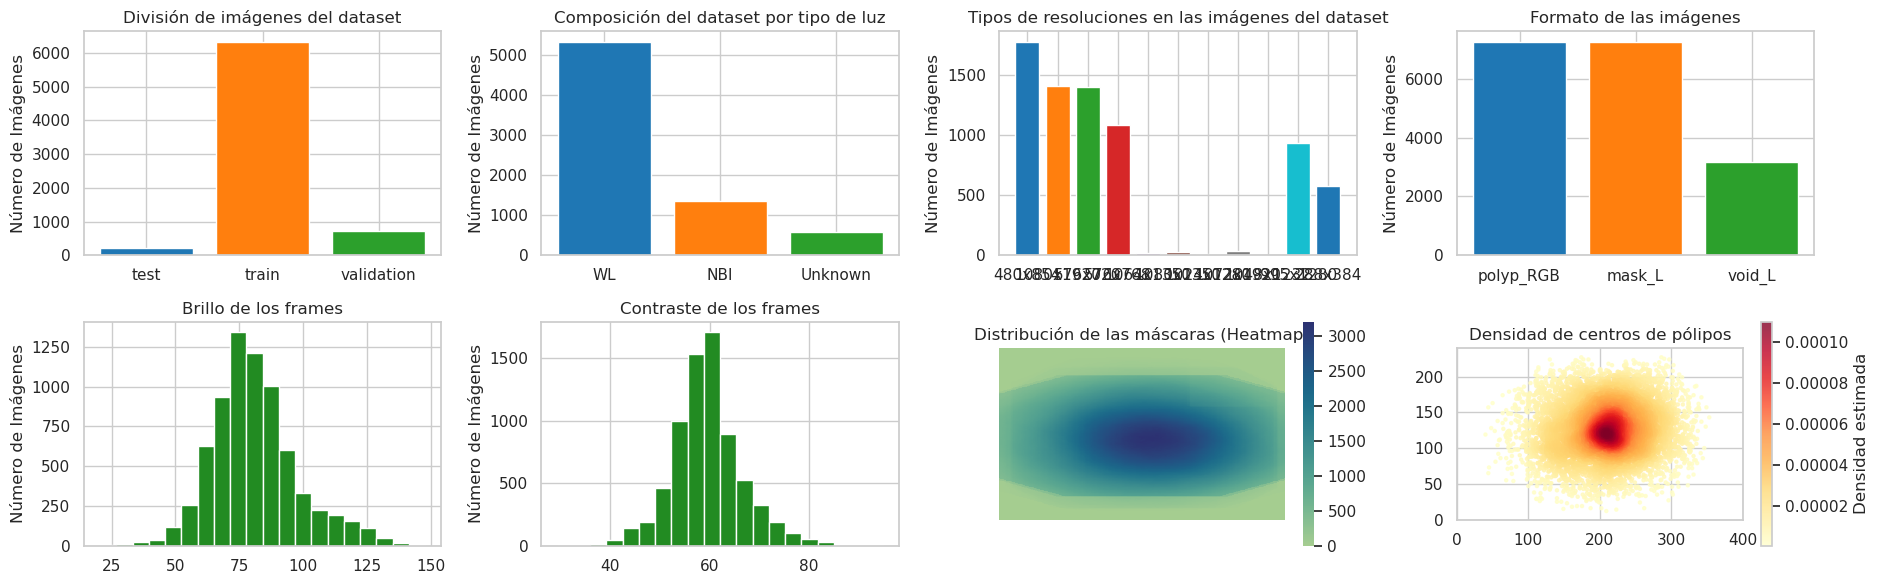

In [10]:
dt_Piccolo.graph_summary()

Finalmente veamos una muestra de una imágen aleatoria y su aspecto con la bbox

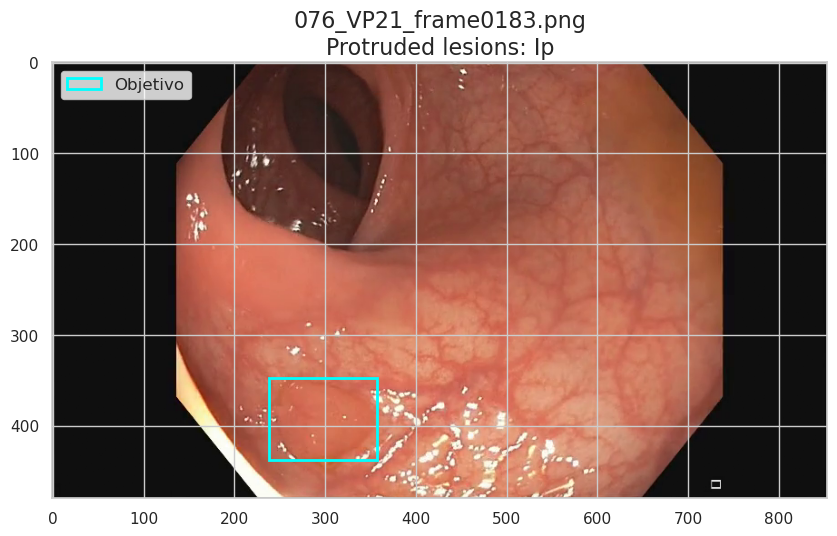

In [11]:
import random

# mostramos aleatoriamente una imágen del dataset
rand_key = random.choice(list(dt_Piccolo.dict.keys()))
dt_Piccolo.show_image(rand_key)

## Entrenamiento de DenseNet121


Para esta segunda entrenaremos el modelo de [DenseNet121](https://pprp.github.io/timm/models/densenet/) **de la librería timm**,
con las imágenes del dataset de Piccolo, con la peculiaridad que trataremos con 
un modelo modificado para devolver solo las bboxes.

#### Pasos del entrenemiento
1. **Modificaremos el modelo** para entrenar y devolver tan solo las bboxes ya que 
DenseNet121 ofrece la arquitectura del encoder ViT por lo que **añadiremos un head de detección**, en este caso una **MLP**, que devuelva las bboxes 

2. **Preparar todo para el entrenamiento**, esto son elementos como el 
optimizador y la función de pérdida además de juntar definitivamente los datos
en los splits adecuados y DataLoaders para usarlos en la función de entrenamiento

3. **Entrenar** el modelo y ir obteniendo datos del rendimiento del mismo para
poder mostrarlos más adelante

In [12]:
import torch.nn as nn


"""
    Vamos a modificar la salida de YOLOv8 para obtener uhna única salida con 
    una bbox ya que es lo que buscamos con nuestro modelo.
"""
class DetectionDenseNet(nn.Module):
    def __init__(self, backbone_model, in_features=1024, hidden_dim=384):
        super(DetectionDenseNet, self).__init__()  # iniciamos la clase padre antes evitar errores
        self.backbone = backbone_model

        # Cabeza de detección de bboxes
        self.bbox_head = nn.Sequential(
            nn.Linear(in_features, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 4)  # [xmin, ymin, xmax, ymax]
        )

    """
    Modificamos la salida de [batch_size, num_pred, 6] siendo la útlima dimension;
    (x_center, y_center, width, height, confidence, class_id) para tener simplemente
    la bbox en formato YOLO: (x_center, y_center, width, height)
    """
    def forward(self, x):
        features = self.backbone(x)         # Extraer características
        bboxes = self.bbox_head(features)   # Predecir coordenadas

        return {'pred_bboxes': bboxes}

#### Preparar el entrenamiento
Una vez modificado el modelo solo debemos preparar el entrenamiento, es decir:
- Definir los dataloders
- Cargar el modelo personaliazdo
- Definir las funciones de pérdida y optimizadores
- Definir una función de entrenamiento

Utilizaremos el **optimizador Adalain** ya que es el usado en Yolos-base y la 
**loss fuction complete_box_iou_loss** ya que refleja de mejor manera las diferencias
entre las bbox comparadas, además de tener en cuenta distancias de centros y otras
comparaciónes que hacen muy completa esta loss fucntion para detección.

In [13]:
import timm

# Cargamos el modelo sin capa de clasificación.
backbone = timm.create_model('densenet121', pretrained=True, num_classes=0)

model = DetectionDenseNet(backbone)
model.train()

DetectionDenseNet(
  (backbone): DenseNet(
    (features): Sequential(
      (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (norm0): BatchNormAct2d(
        64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
        (drop): Identity()
        (act): ReLU(inplace=True)
      )
      (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (denseblock1): DenseBlock(
        (denselayer1): DenseLayer(
          (norm1): BatchNormAct2d(
            64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): ReLU(inplace=True)
          )
          (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (norm2): BatchNormAct2d(
            128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): ReLU(inplace=True)
          )
          (conv2): Conv2d(128, 

#### Entrenamiento

Ahora por fin pasamos a entrenar el modelo y recopilar los dátos de análisis 
para ellos obtenemos el IoU de las bboxes, ya que al ser areas en al imágen no 
podemos medir un "accuracy" tal cual.

**IoU** es una métrica usada para este
tipo de situaciones en las que se calcula: **IoU=Area_interseccion/Area_union** 
por lo que es importante tener en cuenta que **un IoU 1 es una coincidencia exacta**



Resumen TRAIN:
Total imágenes: 6318
Composición del dataset:
Resoluciónes: total distintas resoluciones 11
	480x854: 1208	1080x1920: 1039	576x720: 1398	576x768: 1078	1064x1350: 17	1080x1350: 23	1024x1280: 12	1072x1920: 33	1048x1232: 1	995x1280: 930	288x384: 579

Tipos de luz:
	WL: 4717	NBI: 1022	Unknown: 579

Splits:
	train: 6318

Canales:
	polyp_RGB: 6318	mask_L: 6318	void_L: 2247

Tipos de lesión:
	Flat elevated lesions: 0-lla: 1012	Protruded lesions: Ip: 268	Adenocarcinoma: 223	Protruded lesions: Ips: 187	Protruded lesions: Is: 366	Flat elevated lesions:0-lla/c: 146	Flat lesions: 0-llb: 45	Unknown: 4071

Volumen medio de los pólipos respecto a la imagen:	13.12644054072072%
Volumen medio de las bbox respecto a la imagen:	62.498448683169%
Distancia media del centro del pólipos al centro de la imagen:	57.824173305543894px


Resumen VALIDATION:
Total imágenes: 707
Composición del dataset:
Resoluciónes: total distintas resoluciones 2
	480x854: 340	1080x1920: 367

Tipos de luz:
	WL: 467

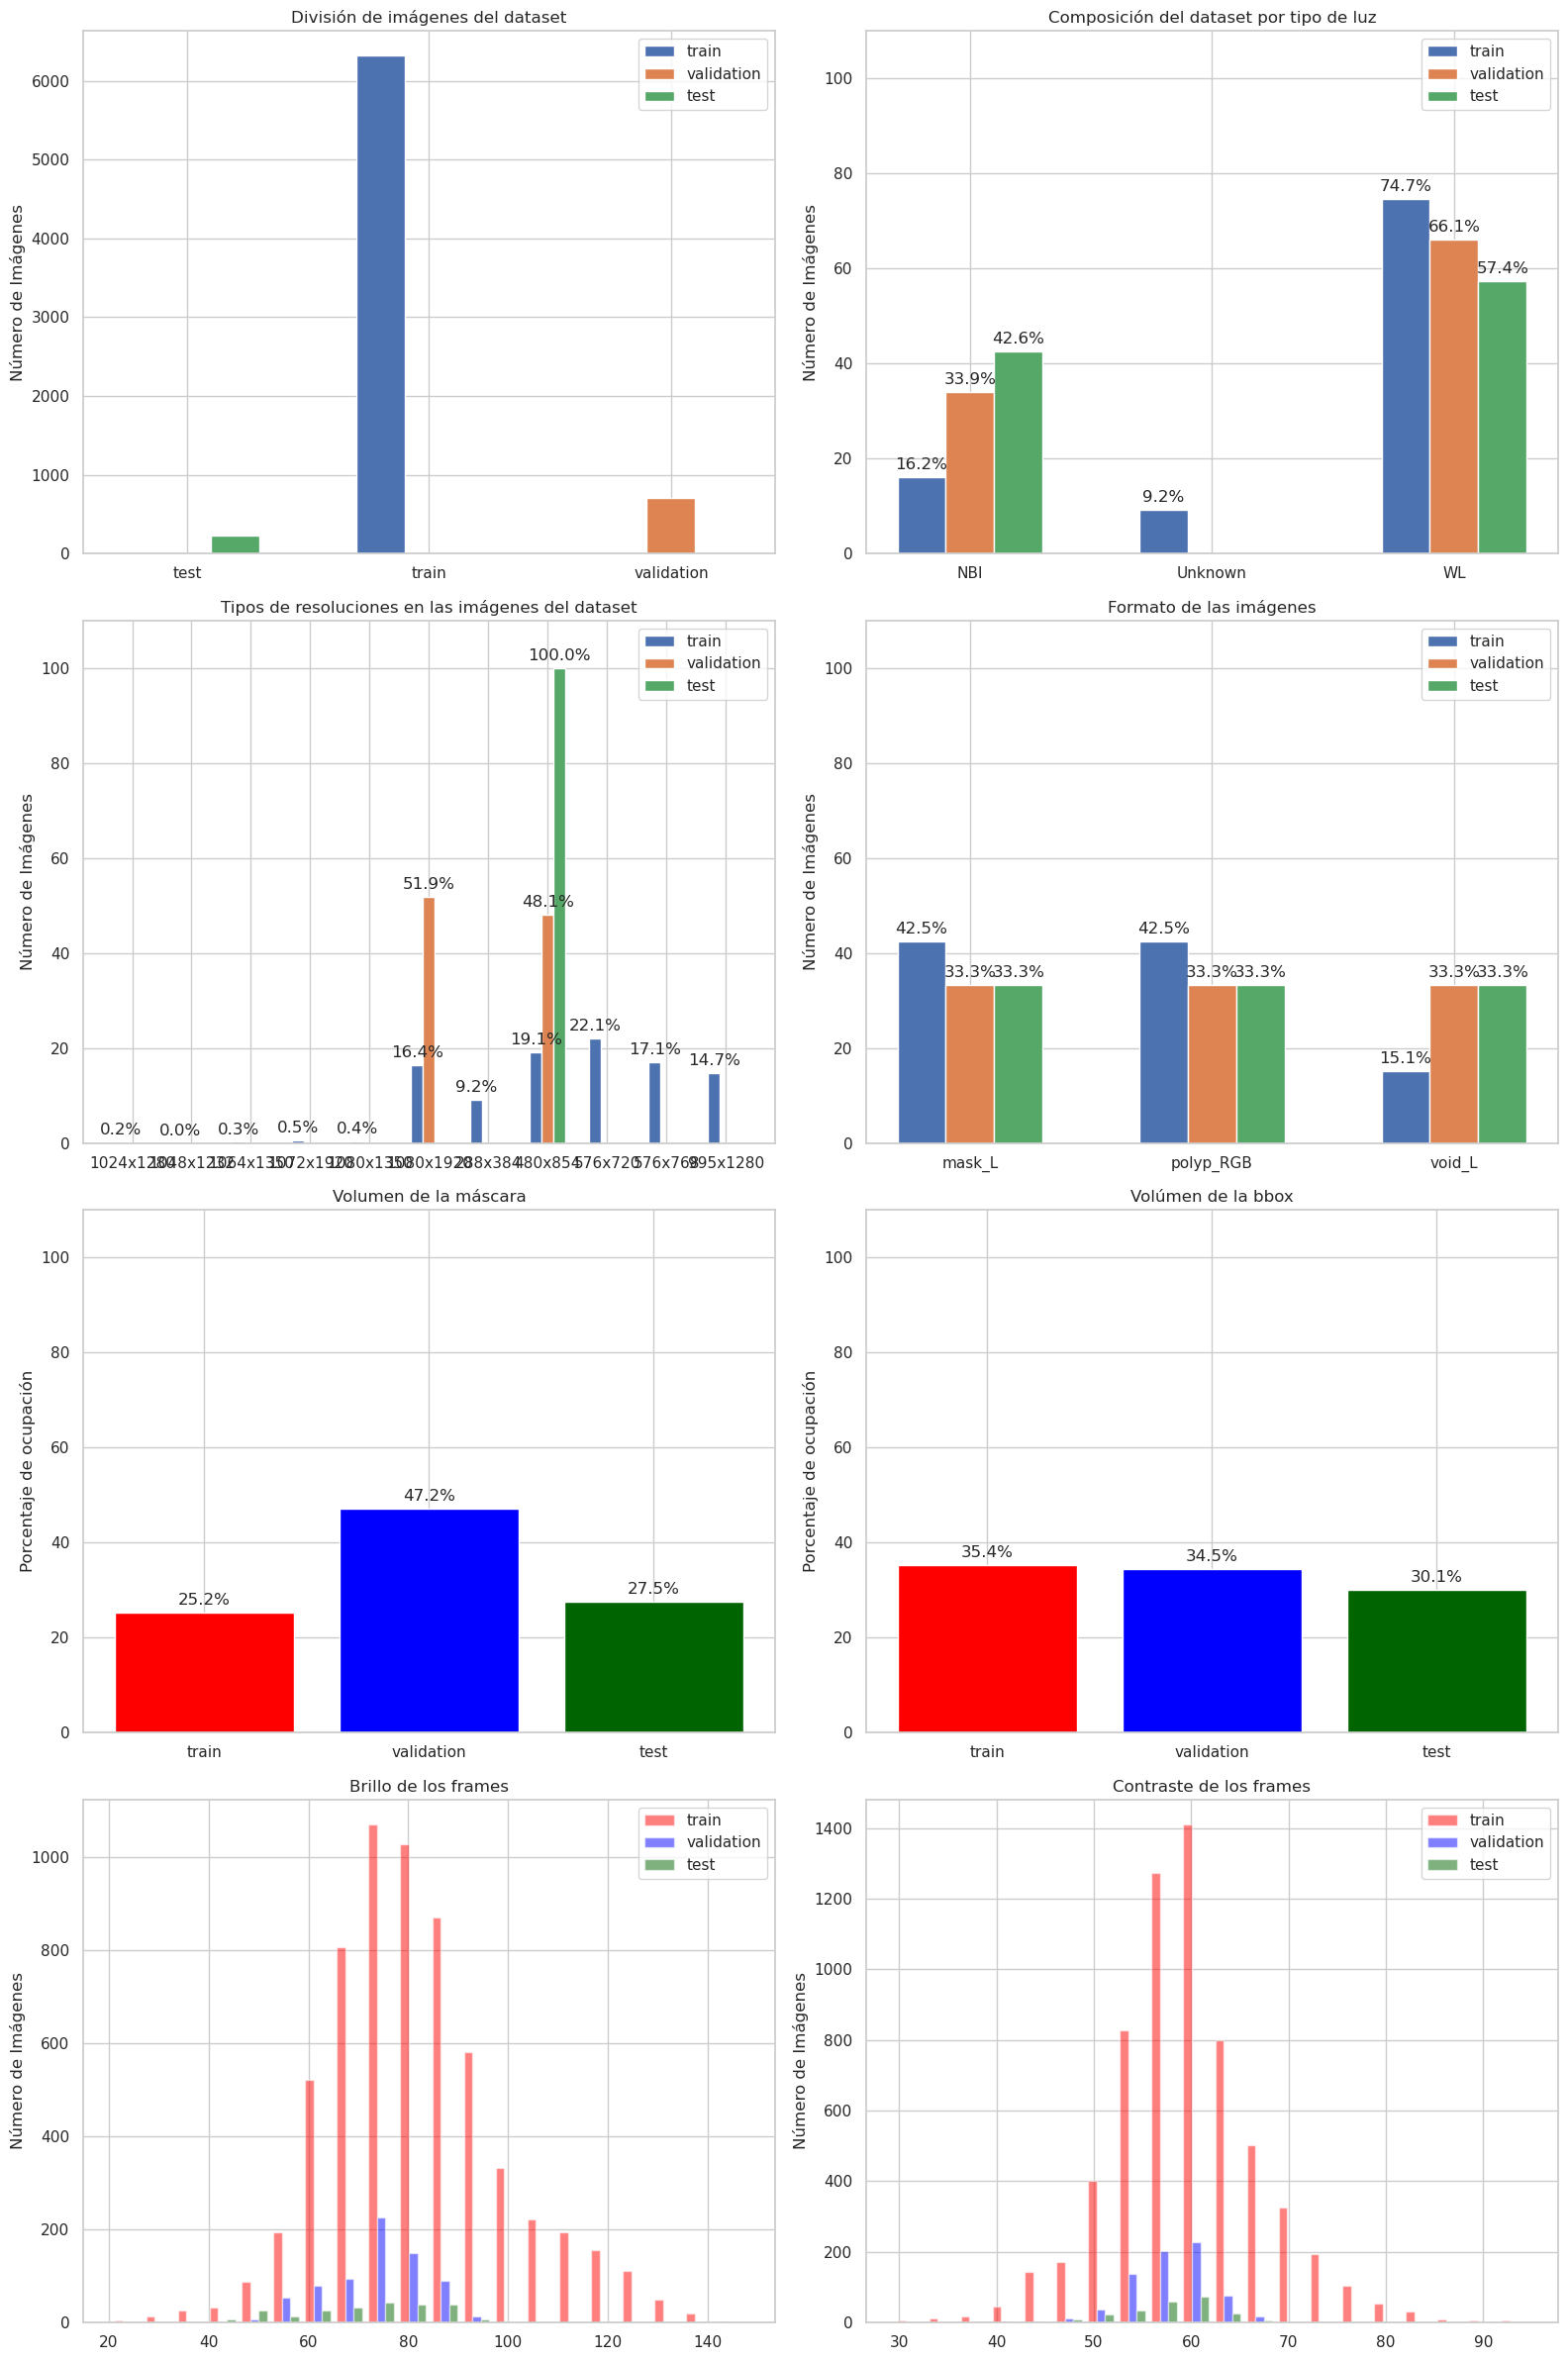

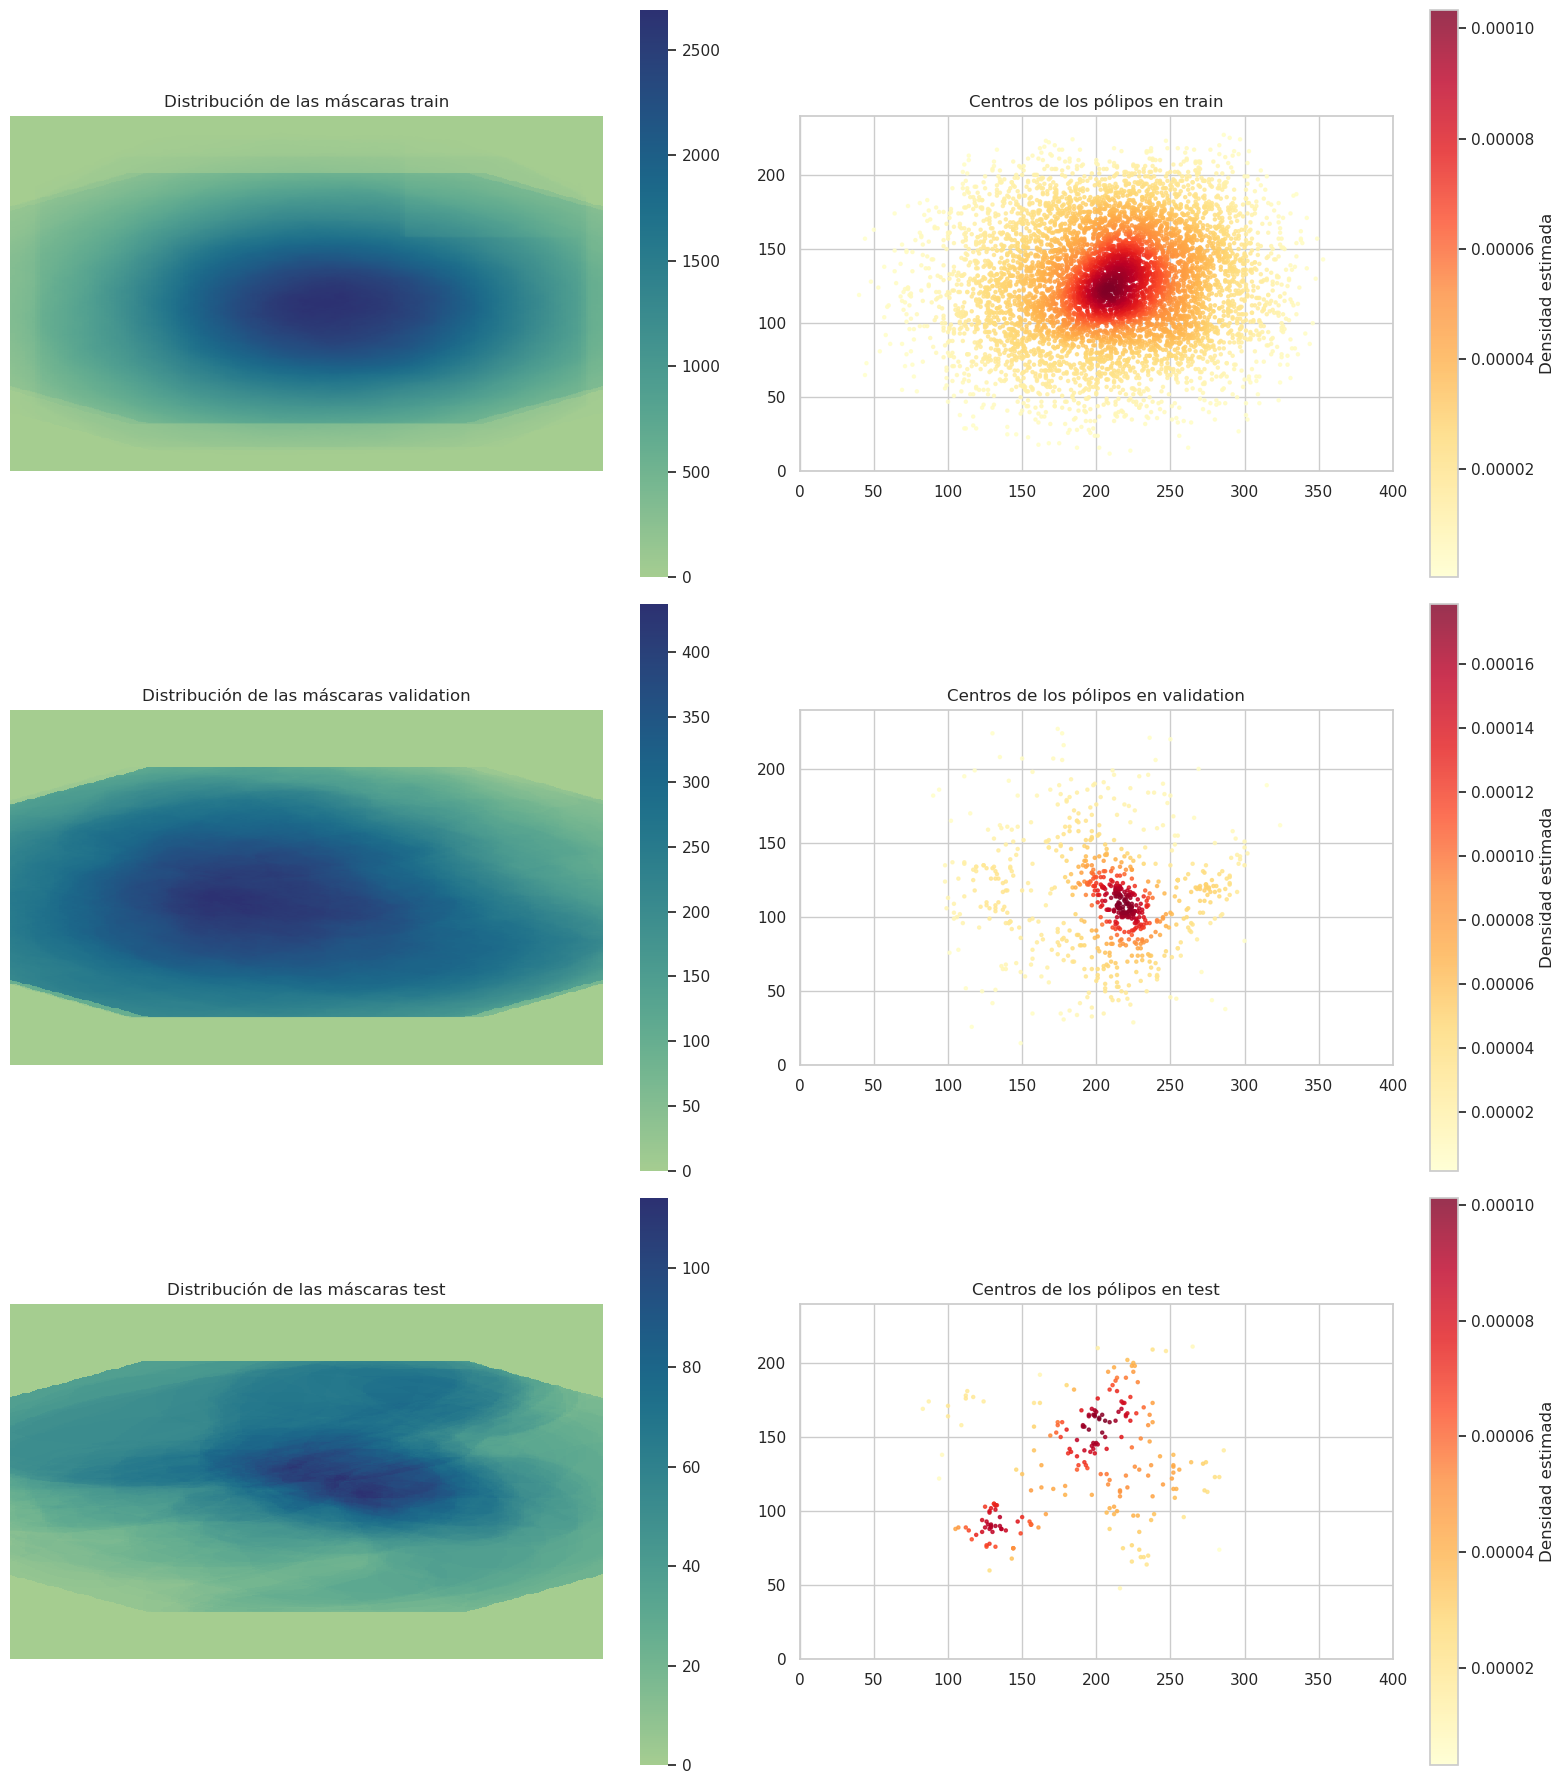

Entrenando en GPU 3
00:00 entrenamiento comenzado num épocas: 20
Época 0 11:19 
Época 0  Loss train 0.0596  IoU train 0.4570 
Época 0  Loss valid 0.0620  IoU valid 0.4125 
Época 1 22:43 
Época 1  Loss train 0.0425  IoU train 0.5928 
Época 1  Loss valid 0.0545  IoU valid 0.4813 
Época 2 34:10 
Época 2  Loss train 0.0372  IoU train 0.6430 
Época 2  Loss valid 0.0529  IoU valid 0.4966 
Época 3 45:31 
Época 3  Loss train 0.0338  IoU train 0.6747 
Época 3  Loss valid 0.0495  IoU valid 0.5280 
Época 4 57:00 
Época 4  Loss train 0.0308  IoU train 0.7039 
Época 4  Loss valid 0.0504  IoU valid 0.5214 
Época 5 68:26 
Época 5  Loss train 0.0283  IoU train 0.7274 
Época 5  Loss valid 0.0467  IoU valid 0.5548 
Época 6 79:45 
Época 6  Loss train 0.0269  IoU train 0.7398 
Época 6  Loss valid 0.0482  IoU valid 0.5403 
Época 7 91:09 
Época 7  Loss train 0.0254  IoU train 0.7541 
Época 7  Loss valid 0.0484  IoU valid 0.5387 
Época 8 102:32 
Época 8  Loss train 0.0246  IoU train 0.7616 
Época 8  Loss val

In [14]:
from utils import TrainModel as trm
from torch.optim import Adam
from torchvision.ops import complete_box_iou_loss
import json

# definimos los parametros del entrenamiento 🏃‍♂
MODEL_NAME = "DenseNet"
NUM_EPOCH = 20              # 🔄 Numero de epocas del entrenamiento 
BATCH_SIZE = 10             # 👝 Numero de imágenes por batch
TRAIN_RES = (384, 384)      # 📷 Resolucion entreno
RESULTS_JSON = f"../../resultados/{DS_NAME}_{MODEL_NAME}_{NUM_EPOCH}EP_{TRAIN_RES[0]}x{TRAIN_RES[1]}.json"
RESULTS_IMG = f"../../resultados/{DS_NAME}_{MODEL_NAME}_{NUM_EPOCH}EP_{TRAIN_RES[0]}x{TRAIN_RES[1]}.png"
json_exists = False

# Obtener los diccionarios con formato de entrenamiento
train_loader, val_loader, test_loader = dt_Piccolo.get_dataloaders(
                                            BATCH_SIZE, use_premade_splits=True)

# definimos el optimizador y la loss function
def loss_fn(target, pred):
    return complete_box_iou_loss(pred, target, reduction='mean')

optimizer = Adam(model.parameters(), lr=5e-5)
trainer = trm(model, loss_fn=loss_fn, optim=optimizer)

# si ya tenemos los resulados no volvemos a entrenar
if os.path.isfile(RESULTS_JSON):
    with open(RESULTS_JSON, "r", encoding="utf-8") as json_file:
            train_results = json.load(json_file)
    json_exists = True

if not json_exists:
    train_results = trainer.train_model(NUM_EPOCH, TRAIN_RES, 
                                    train_loader, val_loader, test_loader)

    # guardamos los datos
    with open(RESULTS_JSON, "w", encoding="utf-8") as json_file:
        json.dump(train_results, json_file)  # `indent=4` para formato legible

## Análisis de los resultados

Una vez entrenado el modelo y finalizada la obtencion de datos durante el entrenamiento,
además de disponer de los datos de test vamos a graficar los resultados y ver 
que tal ha ido el entrenamiento.

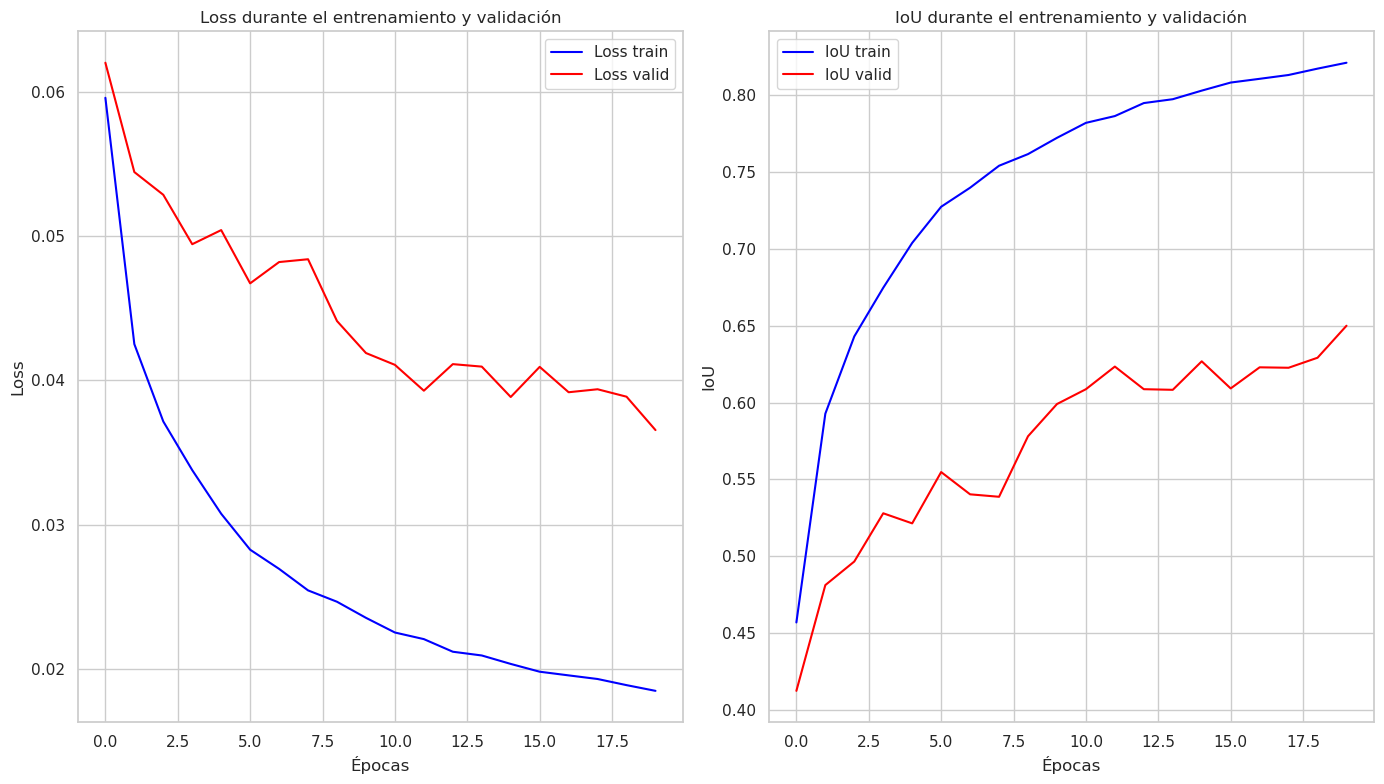

End of training!
-------------------- FINAL RESULTS ------------------------
|     - Test loss:	0.034422                      |
|     - Test IoU:	0.672                        |
-----------------------------------------------------------


In [15]:
trainer.show_results(train_results, save_img=True, img_name=RESULTS_IMG)